# Задание 3 — Аномалии и отказы оборудования


In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'psycopg2-binary', 'boto3', 'pyarrow', 's3fs', '--quiet'], check=True)


CompletedProcess(args=['/opt/conda/bin/python', '-m', 'pip', 'install', 'psycopg2-binary', 'boto3', 'pyarrow', 's3fs', '--quiet'], returncode=0)

In [2]:
import os, io, warnings
import boto3
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sqlalchemy import create_engine
from scipy import stats
from sklearn.ensemble import IsolationForest

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_theme(style='whitegrid')

PG_URI = (
    f"postgresql+psycopg2://"
    f"{os.getenv('PG_USER','oilfield')}:{os.getenv('PG_PASSWORD','oilfield123')}"
    f"@{os.getenv('PG_HOST','postgres')}:{os.getenv('PG_PORT','5432')}"
    f"/{os.getenv('PG_DB','oilfield')}"
)
MINIO_ENDPOINT   = os.getenv('MINIO_ENDPOINT',   'http://minio:9000')
MINIO_ACCESS_KEY = os.getenv('MINIO_ACCESS_KEY', 'minioadmin')
MINIO_SECRET_KEY = os.getenv('MINIO_SECRET_KEY', 'minioadmin123')
BUCKET           = os.getenv('MINIO_BUCKET',     'oilfield')

engine = create_engine(PG_URI)

s3 = boto3.client(
    's3',
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_ACCESS_KEY,
    aws_secret_access_key=MINIO_SECRET_KEY,
)

def read_parquet(bucket, prefix):
    resp = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)
    frames = []
    for obj in resp.get('Contents', []):
        if obj['Key'].endswith('.parquet'):
            buf = io.BytesIO()
            s3.download_fileobj(bucket, obj['Key'], buf)
            buf.seek(0)
            frames.append(pq.read_table(buf).to_pandas())
    return pd.concat(frames, ignore_index=True)



## 1. Загрузка данных


In [3]:
sensors_df  = read_parquet(BUCKET, 'pump_sensors/')
failures_df = read_parquet(BUCKET, 'pump_failures/')

sensors_df['recorded_at']  = pd.to_datetime(sensors_df['recorded_at'])
failures_df['failed_at']   = pd.to_datetime(failures_df['failed_at'])

print(f'pump_sensors:  {sensors_df.shape}')
print(f'pump_failures: {failures_df.shape}')
display(sensors_df.describe())

pump_sensors:  (500, 13)
pump_failures: (40, 7)


,sensor_id,well_id,recorded_at,vibration_mm_s,temperature_c,current_a,rpm,vibration_mm_s_zscore,temperature_c_zscore,current_a_zscore,rpm_zscore,year,month
count,500.000000,500.000000,500,500.000000,500.000000,500.000000,500.000000,5.000000e+02,500.000000,5.000000e+02,5.000000e+02,500.0,500.0
mean,250.500000,8.400000,2026-04-19 20:11:18.809726464,1.638152,65.860260,33.099714,1398.098320,2.000000e-07,0.000001,-6.000000e-07,-4.000000e-07,2026.0,4.0
min,1.000000,1.000000,2026-04-17 19:11:18.809726,0.501000,55.030000,28.003000,1329.600000,-9.205000e-01,-1.532700,-1.381500e+00,-2.369900e+00,2026.0,4.0
25%,125.750000,4.000000,2026-04-18 19:11:18.809725952,1.011500,60.375000,30.333000,1373.322500,-5.072750e-01,-0.776300,-7.499500e-01,-8.572250e-01,2026.0,4.0
50%,250.500000,7.500000,2026-04-19 20:11:18.809725952,1.548750,65.710000,32.880000,1397.715000,-7.240000e-02,-0.021250,-5.955000e-02,-1.330000e-02,2026.0,4.0
75%,375.250000,13.000000,2026-04-20 21:11:18.809725952,2.008850,70.647500,35.522500,1422.557500,3.001000e-01,0.677475,6.567250e-01,8.462500e-01,2026.0,4.0
max,500.000000,17.000000,2026-04-21 21:11:18.809726,14.359100,109.040000,59.876000,1489.480000,1.029780e+01,6.110700,7.257800e+00,3.161600e+00,2026.0,4.0
std,144.481833,5.375667,NaN,1.235311,7.066233,3.689329,28.903617,1.000001e+00,0.999999,1.000002e+00,1.000001e+00,0.0,0.0


## 2. Z-score аномалии


In [4]:
SENSOR_COLS = ['vibration_mm_s', 'temperature_c', 'current_a', 'rpm']
Z_THRESHOLD = 3.0

for col in SENSOR_COLS:
    sensors_df[f'z_{col}'] = np.abs(stats.zscore(sensors_df[col].fillna(sensors_df[col].mean())))

sensors_df['z_anomaly'] = (sensors_df[[f'z_{c}' for c in SENSOR_COLS]] > Z_THRESHOLD).any(axis=1).astype(int)
print(f'Z-score аномалий: {sensors_df["z_anomaly"].sum()} из {len(sensors_df)} ({sensors_df["z_anomaly"].mean()*100:.1f}%)')

Z-score аномалий: 7 из 500 (1.4%)


## 3. Isolation Forest


In [5]:
X = sensors_df[SENSOR_COLS].fillna(sensors_df[SENSOR_COLS].mean())

iso = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
sensors_df['if_label'] = iso.fit_predict(X)  # -1 = anomaly, 1 = normal
sensors_df['if_anomaly'] = (sensors_df['if_label'] == -1).astype(int)

print(f'Isolation Forest аномалий: {sensors_df["if_anomaly"].sum()} из {len(sensors_df)} ({sensors_df["if_anomaly"].mean()*100:.1f}%)')

Isolation Forest аномалий: 25 из 500 (5.0%)


## 4. Risk Score


In [6]:
sensors_df['risk_score'] = sensors_df['z_anomaly'] + sensors_df['if_anomaly']

print('Распределение risk_score:')
print(sensors_df['risk_score'].value_counts().sort_index())

well_risk = (
    sensors_df.groupby('well_id')
    .agg(avg_risk=('risk_score','mean'), max_risk=('risk_score','max'),
         total_anomalies=('if_anomaly','sum'))
    .reset_index().sort_values('avg_risk', ascending=False)
)
display(well_risk)

Распределение risk_score:
risk_score
0    475
1     18
2      7
Name: count, dtype: int64


,well_id,avg_risk,max_risk,total_anomalies
4,7,0.38,2,13
5,8,0.06,2,2
6,11,0.06,1,3
9,17,0.06,1,3
1,2,0.04,1,2
0,1,0.02,1,1
7,13,0.02,1,1
2,4,0.00,0,0
3,5,0.00,0,0
8,16,0.00,0,0


## 5. График 1 — Аномалии по времени


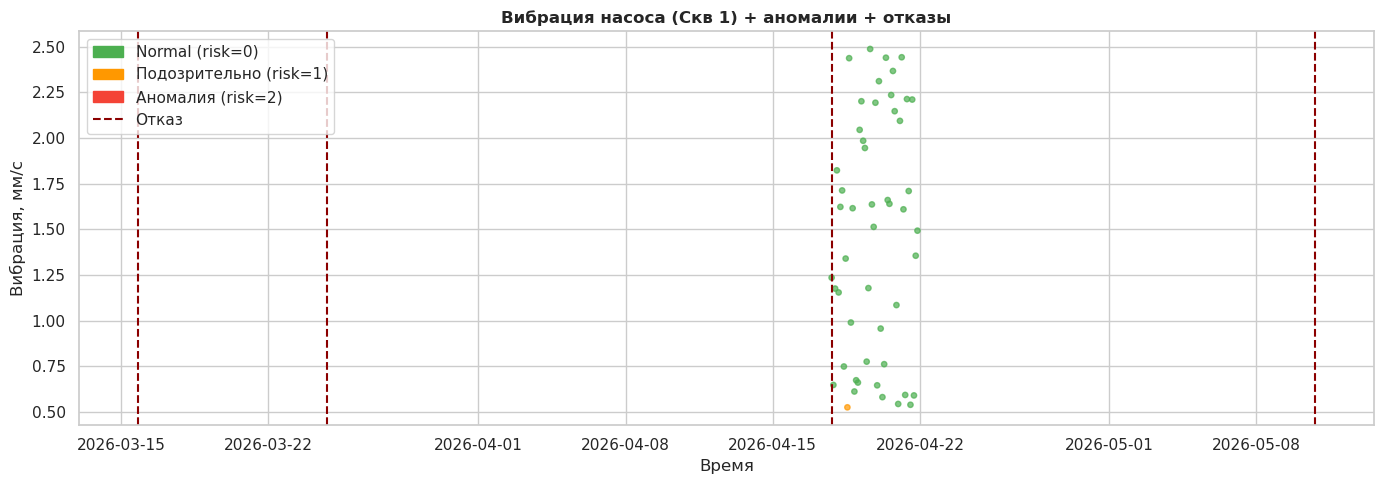

In [7]:
top_well = failures_df['well_id'].value_counts().index[0]
s = sensors_df[sensors_df['well_id'] == top_well].sort_values('recorded_at')
f = failures_df[failures_df['well_id'] == top_well]

colors = s['risk_score'].map({0:'#4CAF50', 1:'#FF9800', 2:'#F44336'})

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(s['recorded_at'], s['vibration_mm_s'],
           c=colors, s=15, alpha=0.7, zorder=2)

for _, row in f.iterrows():
    ax.axvline(row['failed_at'], color='darkred', linestyle='--', linewidth=1.5,
               label='Отказ' if _ == f.index[0] else '')

patches = [
    mpatches.Patch(color='#4CAF50', label='Normal (risk=0)'),
    mpatches.Patch(color='#FF9800', label='Подозрительно (risk=1)'),
    mpatches.Patch(color='#F44336', label='Аномалия (risk=2)'),
]
ax.legend(handles=patches + [plt.Line2D([0],[0], color='darkred', linestyle='--', label='Отказ')], loc='upper left')
ax.set_xlabel('Время')
ax.set_ylabel('Вибрация, мм/с')
ax.set_title(f'Вибрация насоса (Скв {top_well}) + аномалии + отказы', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. График 2 — Box plot: вибрация normal vs anomaly


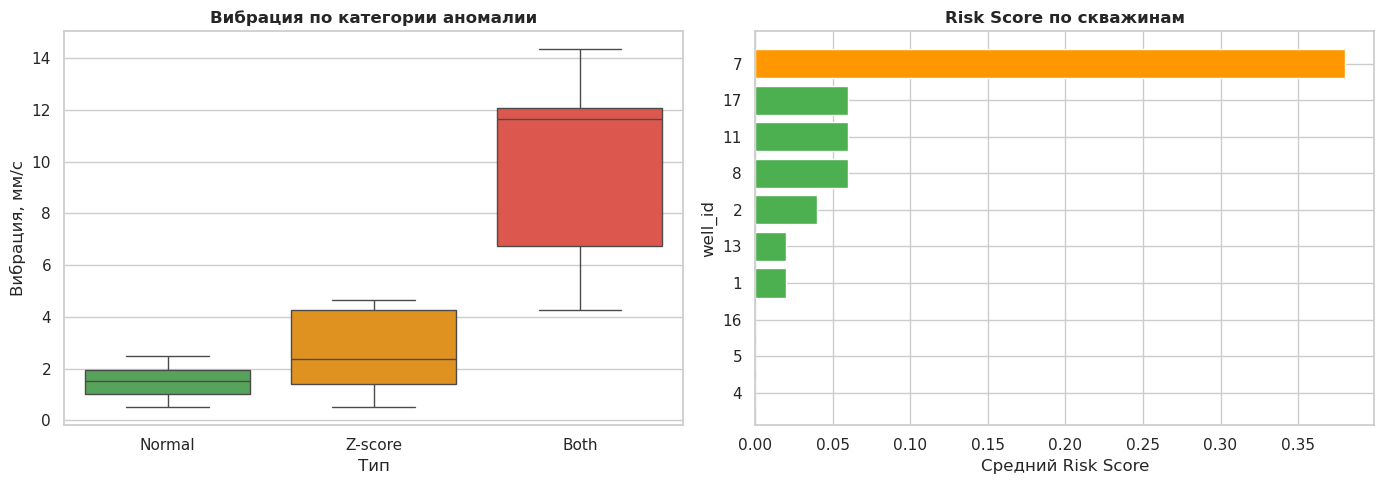

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sensors_df['risk_label'] = sensors_df['risk_score'].map({0:'Normal', 1:'Z-score', 2:'Both'})
sns.boxplot(data=sensors_df, x='risk_label', y='vibration_mm_s',
            palette={'Normal':'#4CAF50','Z-score':'#FF9800','Both':'#F44336'},
            ax=axes[0], order=['Normal','Z-score','Both'])
axes[0].set_title('Вибрация по категории аномалии', fontweight='bold')
axes[0].set_xlabel('Тип')
axes[0].set_ylabel('Вибрация, мм/с')

well_risk_sorted = well_risk.sort_values('avg_risk', ascending=True)
axes[1].barh(well_risk_sorted['well_id'].astype(str),
             well_risk_sorted['avg_risk'],
             color=['#F44336' if r > 0.5 else '#FF9800' if r > 0.1 else '#4CAF50'
                    for r in well_risk_sorted['avg_risk']])
axes[1].set_title('Risk Score по скважинам', fontweight='bold')
axes[1].set_xlabel('Средний Risk Score')
axes[1].set_ylabel('well_id')

plt.tight_layout()
plt.show()

## 7. Паттерны перед отказом


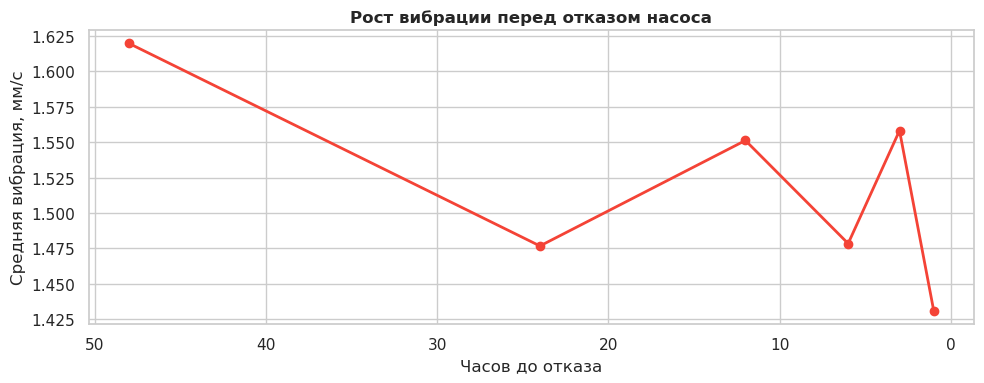

In [9]:
records = []
for _, failure in failures_df.iterrows():
    w = failure['well_id']
    t = failure['failed_at']
    for hours_before in [1, 3, 6, 12, 24, 48]:
        window = sensors_df[
            (sensors_df['well_id'] == w) &
            (sensors_df['recorded_at'] >= t - pd.Timedelta(hours=hours_before)) &
            (sensors_df['recorded_at'] < t)
        ]
        if len(window) > 0:
            records.append({
                'hours_before': hours_before,
                'avg_vibration': window['vibration_mm_s'].mean(),
                'avg_temperature': window['temperature_c'].mean(),
            })

if records:
    pre_fail = pd.DataFrame(records).groupby('hours_before').mean().reset_index()
    pre_fail = pre_fail.sort_values('hours_before', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(pre_fail['hours_before'], pre_fail['avg_vibration'],
            marker='o', color='#F44336', linewidth=2)
    ax.set_xlabel('Часов до отказа')
    ax.set_ylabel('Средняя вибрация, мм/с')
    ax.set_title('Рост вибрации перед отказом насоса', fontweight='bold')
    ax.invert_xaxis()
    plt.tight_layout()
    plt.show()
else:
    print('Нет данных для pre-failure анализа (нет пересечения временных окон)')

## 8. Сохранение в PostgreSQL


In [10]:
cols_to_save = ['well_id','recorded_at','vibration_mm_s','temperature_c',
                'current_a','rpm','z_anomaly','if_anomaly','risk_score']
sensors_df[cols_to_save].to_sql('analytics_anomalies', engine, if_exists='replace', index=False)
print(f'Записано {len(sensors_df)} строк в analytics_anomalies ')

well_risk.to_sql('analytics_well_risk', engine, if_exists='replace', index=False)
print(f'Записано {len(well_risk)} строк в analytics_well_risk ')

Записано 500 строк в analytics_anomalies 
Записано 10 строк в analytics_well_risk 
